# LCU (Generalized for $2^n \times 2^n$ Matrices)
The Linear Combination of Unitaries (LCU) is a foundational protocol in quantum computing that allows us to apply a non-unitary matrix to a quantum state by breaking it down into a sum of unitary matrices. 

Here is the complete step-by-step mathematical derivation of how the LCU protocol successfully applies this operation to a system of arbitrary size, utilizing the transpose of the state preparation matrix to preserve complex coefficients. We will track the state of the quantum computer at each distinct step using the sequence $|\Phi_0\rangle$, $|\Phi_1\rangle$, $|\Phi_2\rangle$, and $|\Phi_3\rangle$.

### The Mathematical Setup

We want to apply an arbitrary non-unitary target matrix $A$ of size $2^n \times 2^n$ to our $n$-qubit data state, $|\psi\rangle$. 

First, we decompose $A$ into a sum of $N$ allowed unitary matrices ($U_k$), each weighted by a coefficient $\alpha_k$ (which can be complex):

$$A = \sum_{k=0}^{N-1} \alpha_k U_k$$

In our generalized case, we utilize the $n$-qubit Pauli strings because they form a complete, orthogonal basis for the vector space of all $2^n \times 2^n$ complex matrices. A Pauli string is a tensor product of single-qubit Pauli matrices $\{I, X, Y, Z\}^{\otimes n}$. Because the Pauli matrices are themselves unitary operators, their tensor products are also unitary. This guarantees that **any** arbitrary $2^n \times 2^n$ matrix $A$ can be perfectly decomposed into a linear combination of unitaries.

Because this Pauli basis is orthogonal, the complex coefficients $\alpha_k$ for any target matrix $A$ corresponding to a Pauli string $P_k$ can be easily and deterministically calculated using the normalized trace inner product:

$$\alpha_k = \frac{1}{2^n} \text{Tr}(A P_k)$$

To ensure the probabilities in our quantum system remain valid, we calculate a normalization constant $\lambda$, which is the sum of the absolute magnitudes of our valid coefficients:

$$\lambda = \sum_k |\alpha_k|$$

Finally, we define the amplitude weights $c_k$ that we will encode into our quantum state. We use the complex square root of the normalized coefficients:

$$c_k = \sqrt{\frac{\alpha_k}{\lambda}}$$

---

### Step 0: The Initial State ($|\Phi_0\rangle$)

We begin with two independent quantum registers:
1.  **The Ancilla Register:** An auxiliary "scratchpad" consisting of $m = \lceil \log_2(N) \rceil$ qubits, initialized to $|0\rangle^{\otimes m}$.
2.  **The Target Register:** Our actual data consisting of $n$ qubits, initialized to $|\psi\rangle$.

The joint starting state of our system is simply the two registers side-by-side:

$$|\Phi_0\rangle = |0\rangle^{\otimes m} |\psi\rangle$$

---

### Step 1: State Preparation ($|\Phi_1\rangle$)

We apply a Preparation operator ($\text{PREP}$) exclusively to the $m$-qubit ancilla register. The goal is to create a superposition where each branch corresponds to one of our unitaries, weighted by $c_k$. 

The operator is defined such that:

$$\text{PREP}|0\rangle^{\otimes m} = \sum_k c_k |k\rangle$$

Applying this to our initial state, we leave the target register unchanged. The new state of the entire system is:

$$|\Phi_1\rangle = \sum_k c_k |k\rangle |\psi\rangle$$

---

### Step 2: The Select Operation ($|\Phi_2\rangle$)

Next, we apply the Select operator ($\text{SEL}$). This is a massive, controlled operation that applies the unitary $U_k$ (the $n$-qubit Pauli string) to the target register *if and only if* the ancilla register is in the binary state $|k\rangle$.

Mathematically, $\text{SEL}$ distributes across the superposition, entangling the specific unitaries with their corresponding ancilla states:

$$|\Phi_2\rangle = \text{SEL} |\Phi_1\rangle$$

$$|\Phi_2\rangle = \sum_k c_k |k\rangle U_k |\psi\rangle$$

At this moment, our desired operations are executing, but the results are trapped in an entangled superposition.

---

### Step 3: Transpose Post-Selection ($|\Phi_3\rangle$)

To extract the answer, we must decouple the ancilla from the target register. We achieve this physically through a strict two-step sequence: first applying a specific gate, and then filtering the results based on a measurement. 

Normally, to reverse a quantum state preparation, we would apply its inverse. Since quantum gates are unitary, the inverse is the conjugate transpose ($\text{PREP}^\dagger = \text{PREP}^{-1}$). However, if we do that here, the complex conjugation inherent to the $\dagger$ operation will conjugate our amplitudes and ruin the phase of our complex coefficients. 

To prevent this, we use the following sequence:

**Apply the Transpose Gate:**
Instead of the inverse, we first apply only the **Transpose** of the preparation operator, $\text{PREP}^T$, to the ancilla register. (Note that for a unitary matrix, $\text{PREP}^T = \overline{\text{PREP}^{-1}}$). 

**Measure and Post-Select:**
Immediately after applying $\text{PREP}^T$, we measure the ancilla register. We discard any runs where the ancillas measure as anything other than zero, and strictly keep the runs where the ancilla register collapses to $|0\rangle^{\otimes m}$ (a process known as post-selection).

**Why do we do it this way?**
In quantum mechanics, the physical act of applying an operator $M$ and then successfully post-selecting on the $|0\rangle$ state is mathematically equivalent to projecting the quantum state onto the "bra" vector $\langle 0|M$. 

Therefore, by physically applying $\text{PREP}^T$ and measuring $|0\rangle^{\otimes m}$, we are mathematically applying the projection $(\langle 0|^{\otimes m}) \text{PREP}^T$. 

Because a standard matrix transpose does *not* involve complex conjugation, this specific sequence generates a "bra" vector that perfectly preserves our original complex amplitudes. Mathematically, we can express this projection as:

$$(\langle 0|^{\otimes m}) \text{PREP}^T = \sum_j c_j \langle j |$$

We apply this projection to the ancilla portion of our entangled state to yield our final, unnormalized target state:

$$|\Phi_3\rangle = \left( \sum_j c_j \langle j | \right) |\Phi_2\rangle$$

$$|\Phi_3\rangle = \left( \sum_j c_j \langle j | \right) \left( \sum_k c_k |k\rangle U_k |\psi\rangle \right)$$

Because quantum basis states form an orthonormal basis ($\langle j | k \rangle = 1$ if $j=k$, and $0$ otherwise). This property collapses the double summation, isolating the terms where the branches match:

$$|\Phi_3\rangle = \sum_k c_k \cdot c_k U_k |\psi\rangle$$

$$|\Phi_3\rangle = \sum_k c_k^2 U_k |\psi\rangle$$

This is the crucial step. By squaring the complex amplitude $c_k$, we perfectly recover our original normalized coefficient:

$$c_k^2 = \left( \sqrt{\frac{\alpha_k}{\lambda}} \right)^2 = \frac{\alpha_k}{\lambda}$$

Substituting this back into the equation yields:

$$|\Phi_3\rangle = \sum_k \frac{\alpha_k}{\lambda} U_k |\psi\rangle$$

Factoring out the constant $\frac{1}{\lambda}$, we reveal our original non-unitary matrix $A$:

$$|\Phi_3\rangle = \frac{1}{\lambda} \sum_k \alpha_k U_k |\psi\rangle$$

$$|\Phi_3\rangle = \frac{A}{\lambda} |\psi\rangle$$

### The Result

By simply verifying that the $m$-qubit ancilla register measures as zero at the end of the circuit, the mathematics guarantees that the target register has successfully collapsed into the state $|\Phi_3\rangle$. We have successfully applied an arbitrary, non-unitary operation to our $n$-qubit data register.

In [32]:
# ==========================================
# 1. USER INPUTS
# ==========================================

import numpy as np

# Define an arbitrary non-unitary target matrix A.
# For n data qubits, the matrix must be of size (2^n x 2^n).
# It can contain real, imaginary, or negative complex numbers.
A = np.array([
    [ 0.12-0.5j, -3.4,       1.1j,      0.0  ],
    [ 2.2,        0.0+0.8j, -0.4,       1.55j],
    [-0.9j,       1.1,      -2.2-0.1j,  0.7  ],
    [ 5.0,       -1.3j,      0.0,       3.14 ]
], dtype=complex)

# Define the initial quantum data state (vector).
# The length must match the dimension of matrix A.
PSI = np.array([-0.5, 1.2j, 3.3-1j, -0.1], dtype=complex)
# Normalize the initial state vector so the sum of its squared magnitudes equals 1.
PSI = PSI / np.linalg.norm(PSI)

print("Matrix A:\n", A)
print("Init state PSI:\n", PSI)

# --- VALIDATION CHECKS ---
# 1. Check if the matrix is square (N x N)
if A.ndim != 2 or A.shape[0] != A.shape[1]:
    raise ValueError(f"CHYBA: Matice A musí být čtvercová (2D pole). Zadána byla matice s tvarem {A.shape}.")
dim_A = A.shape[0]

# 2. Check if the matrix dimension is a valid power of 2 (e.g., 2, 4, 8, 16)
if not np.log2(dim_A).is_integer():
    raise ValueError(f"CHYBA: Rozměr matice A musí být mocnina 2 (např. 2x2, 4x4, 8x8). Zadaný rozměr je {dim_A}x{dim_A}.")

# 3. Check if the size of vector PSI matches the dimension of matrix A
if PSI.ndim != 1:
    raise ValueError(f"CHYBA: Stav PSI musí být 1D vektor. Zadaný tvar je {PSI.shape}.")
if PSI.shape[0] != dim_A:
    raise ValueError(f"CHYBA: Délka vektoru PSI ({PSI.shape[0]}) neodpovídá rozměru matice A ({dim_A}).")

Matrix A:
 [[ 0.12-0.5j  -3.4 +0.j    0.  +1.1j   0.  +0.j  ]
 [ 2.2 +0.j    0.  +0.8j  -0.4 +0.j    0.  +1.55j]
 [-0.  -0.9j   1.1 +0.j   -2.2 -0.1j   0.7 +0.j  ]
 [ 5.  +0.j   -0.  -1.3j   0.  +0.j    3.14+0.j  ]]
Init state PSI:
 [-0.13563141+0.j          0.        +0.32551538j  0.8951673 -0.27126282j
 -0.02712628+0.j        ]


In [33]:
# ==========================================
# 2. PAULI DECOMPOSITION & STATE PREPARATION
# ==========================================

from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import SparsePauliOp

# Calculate the required number of target (data) qubits based on matrix size.
num_target = int(np.log2(A.shape[0]))

# Perform automatic Pauli decomposition of matrix A.
# Qiskit internally calculates the trace inner product: 1/2^n * Tr(A * P)
pauli_op = SparsePauliOp.from_operator(A)

# Extract the resulting Pauli strings (e.g., 'IX', 'ZZ') and their complex coefficients.
paulis = pauli_op.paulis
coeffs = np.array(pauli_op.coeffs)

# Count the number of non-zero terms returned by Qiskit.
num_terms = len(coeffs)

# Determine the number of ancilla qubits required.
# We need enough qubits (k) to represent all non-zero terms, so 2^k >= num_terms.
num_ancilla = int(np.ceil(np.log2(num_terms))) if num_terms > 1 else 1

# Qiskit's StatePreparation strictly requires the input array length to be exactly 2^k.
# We create an array of zeros and insert our valid coefficients into the beginning.
padded_coeffs = np.zeros(2**num_ancilla, dtype=complex)
padded_coeffs[:num_terms] = coeffs

# Calculate the LCU normalization factor lambda (sum of absolute values).
lambda_ = np.abs(padded_coeffs).sum()

# Calculate the amplitudes for the PREP gate.
# In LCU, we encode the square root of the normalized coefficients into the ancilla state.
amplitudes = np.sqrt(padded_coeffs / lambda_)

# Initialize the state preparation (PREP) operator for the ancillas.
prep = StatePreparation(amplitudes, label='PREP')

# Initialize the transpose of PREP. 
# We use the conjugate of the amplitudes to avoid negating the phase during post-selection.
prep_transpose = StatePreparation(amplitudes.conjugate(), inverse=True, label='PREP_transpose')

# Initialize the state preparation operator for our target data state |ψ⟩.
psi_prep = StatePreparation(PSI, label='|ψ⟩')

# --- Output Decomposition Statistics ---
print("--- Pauli Decomposition of Matrix A ---")
print(f"Number of target qubits (n): {num_target}")
print(f"Number of ancilla qubits (k): {num_ancilla}")
print(f"Number of Pauli terms from Qiskit: {num_terms} (padded to {2**num_ancilla} for PREP)\n")

print(f"{'Operator':<10} | {'Coefficient (alpha)'}")
print("-" * 35)
for pauli, coeff in zip(paulis, coeffs):
    print(f"{pauli.to_label():<10} | {np.round(coeff, 4)}")

--- Pauli Decomposition of Matrix A ---
Number of target qubits (n): 2
Number of ancilla qubits (k): 4
Number of Pauli terms from Qiskit: 16 (padded to 16 for PREP)

Operator   | Coefficient (alpha)
-----------------------------------
II         | (0.265+0.05j)
IX         | (-0.125+0j)
IY         | (-0-1.225j)
IZ         | (-1.305-0.35j)
XI         | 0.1125j
XX         | (1.425+0j)
XY         | (-0-0.875j)
XZ         | -0.0125j
YI         | (-1.2125+0j)
YX         | (-0-1.625j)
YY         | (-1.075+0j)
YZ         | (0.2125+0j)
ZI         | (-0.205+0.1j)
ZX         | (-0.475+0j)
ZY         | (-0-1.575j)
ZZ         | (1.365-0.3j)


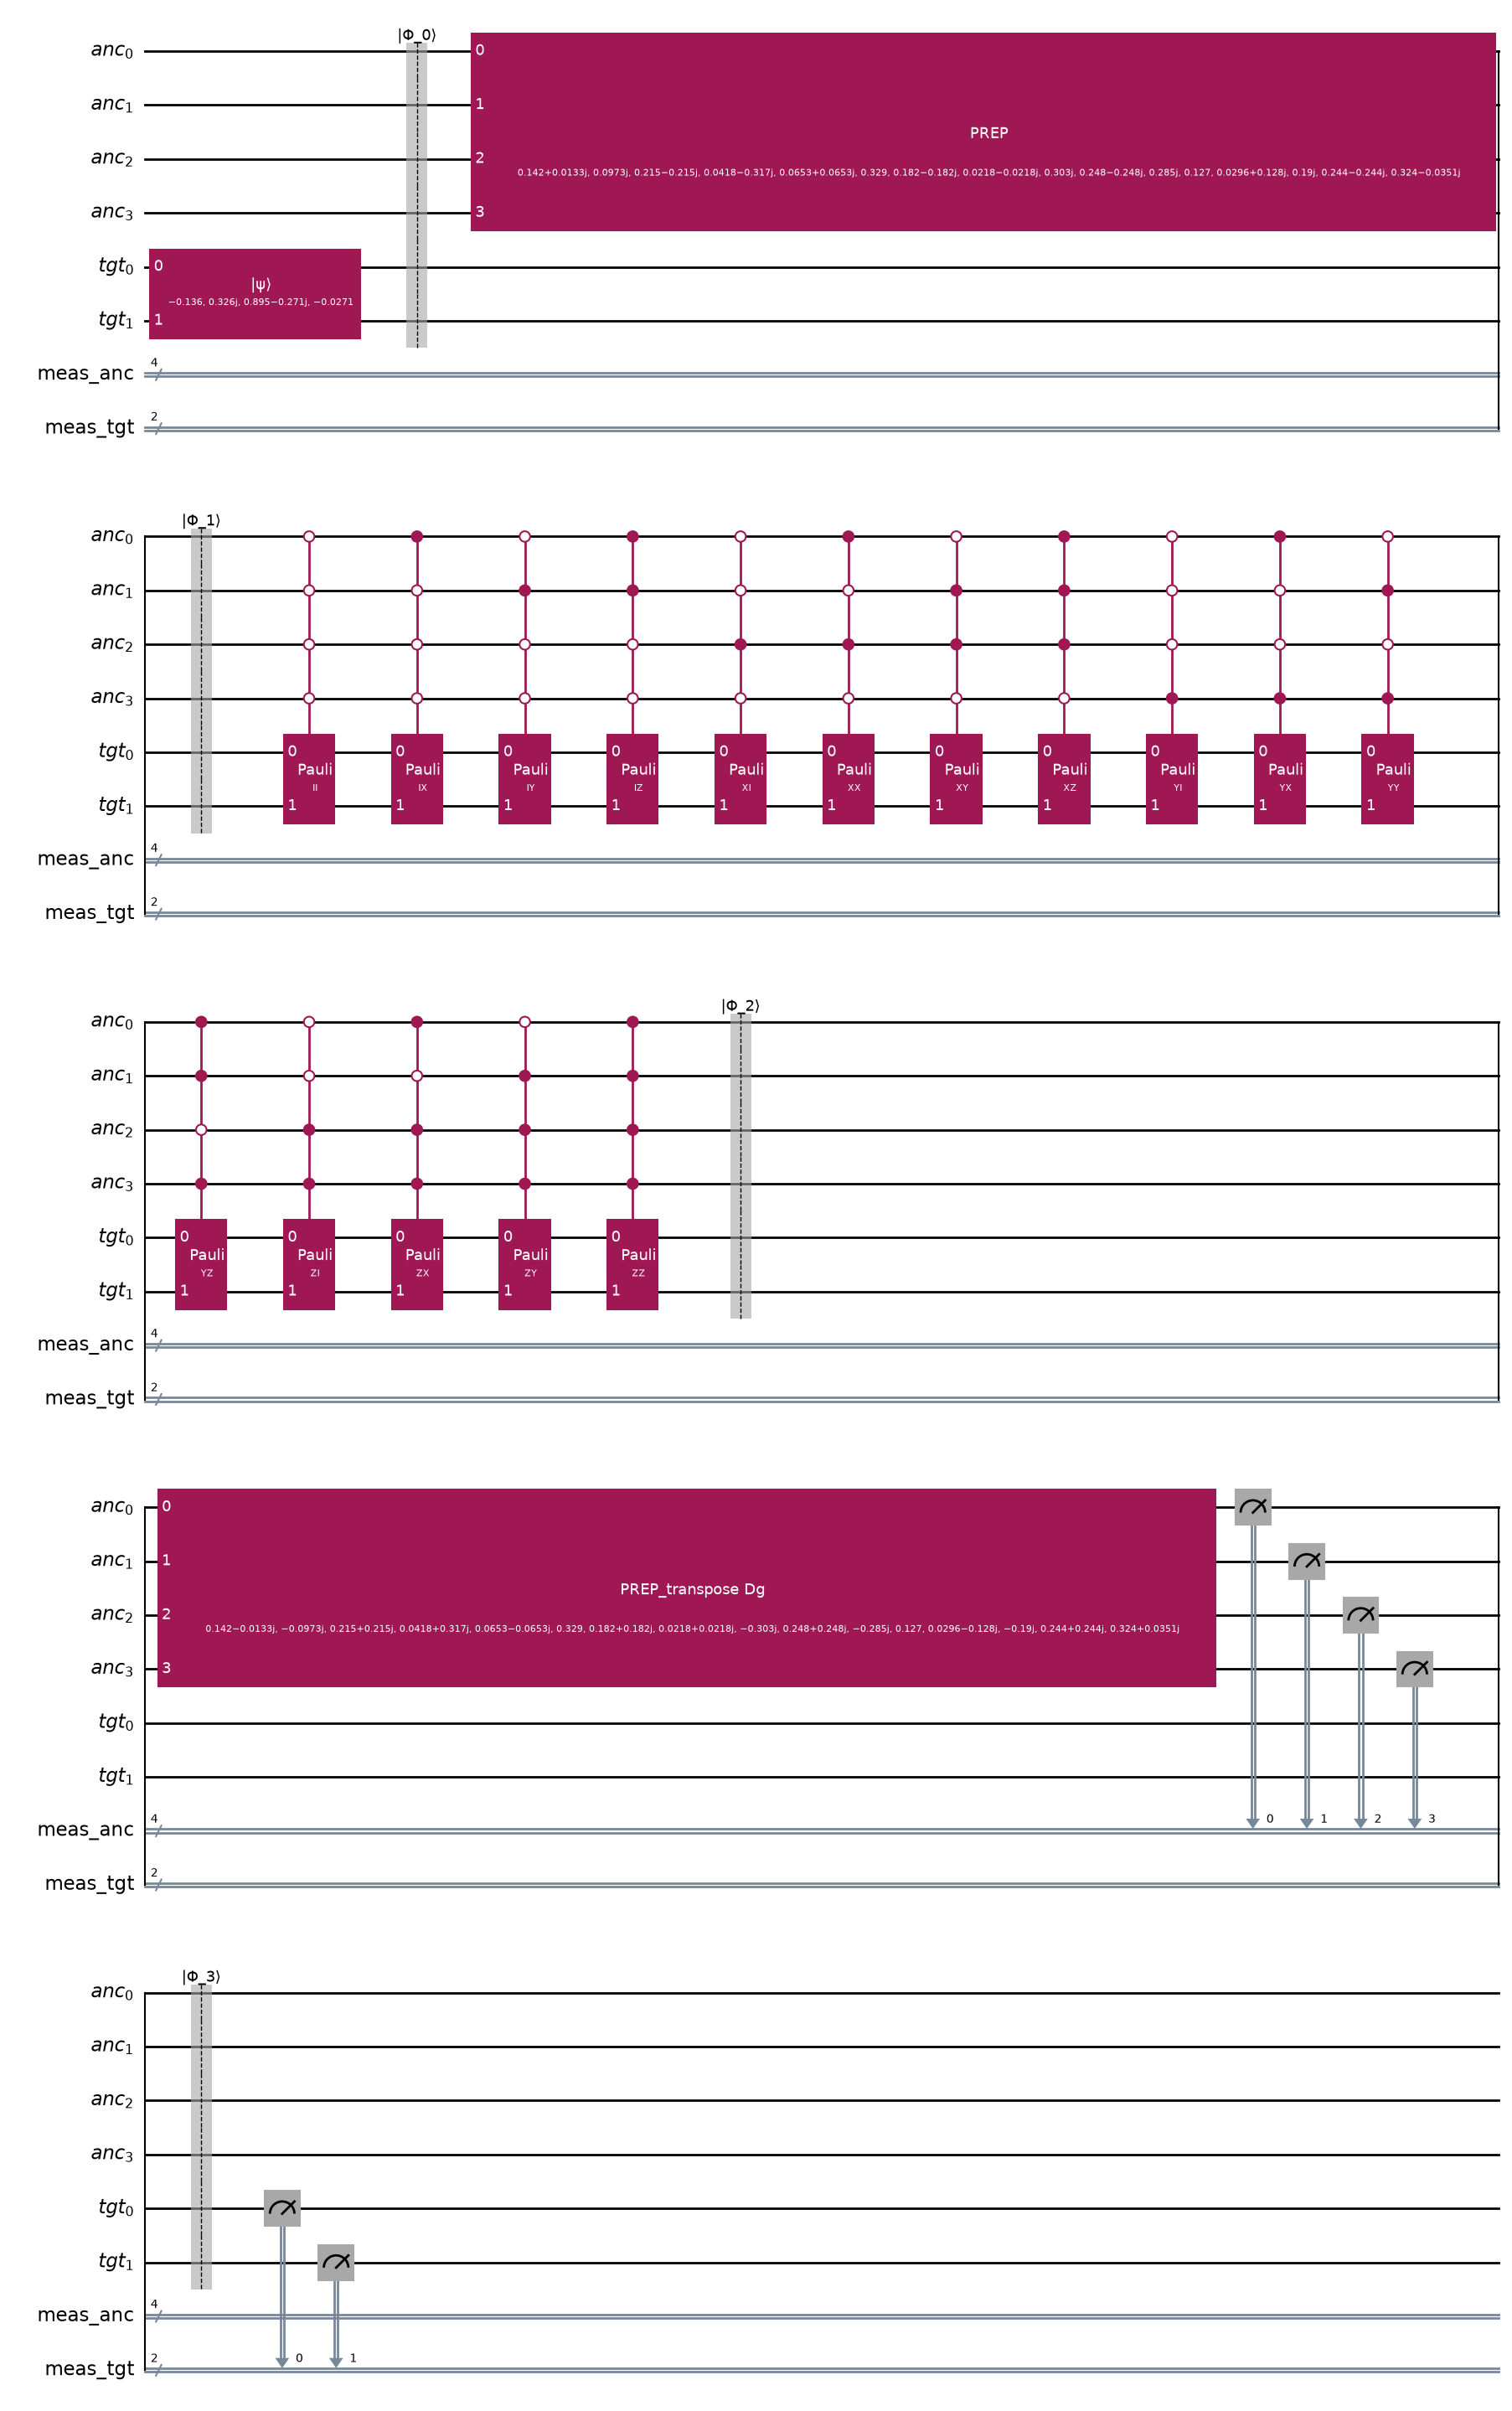

In [34]:
# ==========================================
# 3. QUANTUM CIRCUIT CONSTRUCTION
# ==========================================

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import PauliGate

# Define discrete quantum and classical registers for clarity.
anc = QuantumRegister(num_ancilla, name='anc')
tgt = QuantumRegister(num_target, name='tgt')
cr_anc = ClassicalRegister(num_ancilla, name='meas_anc')
cr_tgt = ClassicalRegister(num_target, name='meas_tgt')

# Initialize the full quantum circuit.
qc = QuantumCircuit(anc, tgt, cr_anc, cr_tgt)

# STEP 0: Prepare the initial data state |ψ⟩ on the target register.
qc.append(psi_prep, tgt)
qc.barrier(label="|Φ_0⟩")

# STEP 1: Apply the PREP operator to the ancilla register to create the weighted superposition.
qc.append(prep, anc)
qc.barrier(label="|Φ_1⟩")

# STEP 2: Apply the Select (SEL) operation.
# We iterate through all non-zero Pauli operators and apply them conditionally.
for idx, pauli_obj in enumerate(paulis):

    # Convert the current loop index into a zero-padded binary string.
    # E.g., if we have 3 ancillas, index 2 becomes '010'.
    ctrl_state = format(idx, f'0{num_ancilla}b')
    
    # Extract the string representation of the Pauli operator (e.g., 'IX').
    pauli_str = pauli_obj.to_label()
    
    # Create the base Pauli gate and attach a multi-qubit control to it.
    # The gate will only trigger if the ancilla register matches the ctrl_state.
    pauli_gate = PauliGate(pauli_str)
    controlled_pauli = pauli_gate.control(num_ancilla, ctrl_state=ctrl_state)
    
    # Append the controlled gate to the circuit. 
    # anc[:] acts as the control qubits, tgt[:] acts as the target qubits.
    qc.append(controlled_pauli, anc[:] + tgt[:])

qc.barrier(label="|Φ_2⟩")

# STEP 3: Decouple the registers using UNPREP (Transpose) and measure the ancillas.
# This prepares the circuit for post-selection.
qc.append(prep_transpose, anc)
qc.measure(anc, cr_anc)
qc.barrier(label="|Φ_3⟩")

# Measure the target qubits to observe the final manipulated data state.
qc.measure(tgt, cr_tgt)

# Draw the circuit visually (requires the 'pylatexenc' package).
display(qc.draw('mpl'))


In [35]:
# ==========================================
# 4. SIMULATION AND VERIFICATION OF RESULTS
# ==========================================

from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np

print("Running simulation (100,000 shots)...")

# 1. Setup the local simulator and compile the abstract circuit into executable instructions.
simulator = AerSimulator(shots=100000)
compiled_qc = transpile(qc, simulator).decompose()

# Execute the job and retrieve the raw measurement counts.
job = simulator.run(compiled_qc)
result = job.result()
counts = result.get_counts()

# 2. Filter for successful states (Post-selection).
# The LCU algorithm only succeeds when the ancilla register collapses entirely to zeros.
target_ancilla_state = '0' * num_ancilla

# Qiskit returns dictionary keys formatted as "target_measurements ancilla_measurements" (e.g., "01 000").
# We split the string, isolate the runs where ancillas measured as 0, and keep only the target outcomes.
filtered_counts = {k.split()[0]: v for k, v in counts.items() if k.endswith(target_ancilla_state)}

# Calculate the empirical probability of the LCU succeeding.
total_successes = sum(filtered_counts.values())
total_shots = sum(counts.values())
success_prob = total_successes / total_shots if total_shots > 0 else 0

print(f"Probability of LCU success (measured {target_ancilla_state} on ancillas): {success_prob:.4f}\n")

# 3. Perform classical analytical calculation to verify the quantum result.
analytical_result = A @ PSI
analytical_result_norm = analytical_result / np.linalg.norm(analytical_result)
analytical_probs = np.abs(analytical_result_norm) ** 2

# 4. Compare the quantum probability distribution with the classical analytical truth.
print("--- Porovnání distribuce pravděpodobností datového stavu ---")
print(f"{'Stav':<10} | {'Kvantový obvod':<20} | {'Analytický výpočet':<20}")
print("-" * 55)

print("--- Comparison of target state probability distribution ---")
print(f"{'State':<10} | {'Quantum Circuit':<20} | {'Analytical Calc':<20}")
print("-" * 55)

# Iterate through every possible target state (0 to 2^n - 1)
for i in range(2**num_target):
    # Convert integer to padded binary string (e.g., 2 -> '010' for a 3-qubit state)
    state_bin = format(i, f'0{num_target}b')
    
    # Calculate the normalized probability observed in the quantum circuit.
    # We divide by total_successes, not total_shots, because we only care about post-selected runs.
    if total_successes > 0:
        sim_prob = filtered_counts.get(state_bin, 0) / total_successes
    else:
        sim_prob = 0.0
        
    print(f"|{state_bin}⟩{'':<6} | {sim_prob:<20.4f} | {analytical_probs[i]:<20.4f}")

Running simulation (100,000 shots)...
Probability of LCU success (measured 0000 on ancillas): 0.0326

--- Porovnání distribuce pravděpodobností datového stavu ---
Stav       | Kvantový obvod       | Analytický výpočet  
-------------------------------------------------------
--- Comparison of target state probability distribution ---
State      | Quantum Circuit      | Analytical Calc     
-------------------------------------------------------
|00⟩       | 0.0129               | 0.0136              
|01⟩       | 0.1367               | 0.1390              
|10⟩       | 0.8314               | 0.8284              
|11⟩       | 0.0190               | 0.0190              
